In [1]:
import optgraphstate as ogs
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from optimization_script import run_optimization
import stim
import igraph as ig
import scipy.io


In [2]:
max_n = 11
max_m = 11

cnots_Naive = []
emitters_Naive = []
cnots_Heur1 = []
emitters_Heu1 = []
for n in range(2, max_n+1):
    for m in range(n, max_m+1):
        with open(f'/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/evas_results/results_summary_grid_{n}by{m}.txt', 'r') as file:
            contents = file.read().strip()
            array = eval(contents)
            cnots_Naive.append(array[0])
            emitters_Naive.append(array[1])
            cnots_Heur1.append(array[2])
            emitters_Heu1.append(array[3])
            




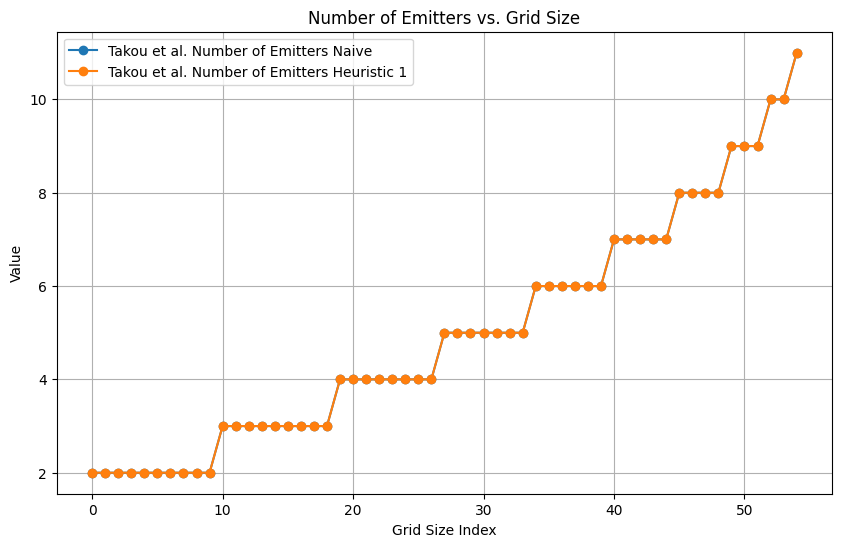

In [3]:
# Create the line plot for emitters_Naive
plt.figure(figsize=(10, 6))
plt.plot(range(len(emitters_Naive)), emitters_Naive, marker='o',label='Takou et al. Number of Emitters Naive')

# Create the line plot for cnots_Naive
plt.plot(range(len(emitters_Heu1)), emitters_Heu1,marker='o' ,label='Takou et al. Number of Emitters Heuristic 1')

# Set the labels
plt.xlabel('Grid Size Index')
plt.ylabel('Value')

# Set the title
plt.title('Number of Emitters vs. Grid Size')

# Add legend
plt.legend()

# Set the y-axis to show only integers
# plt.yticks(range(min(min(emitters_Naive), min(cnots_Naive)), max(max(emitters_Naive), max(cnots_Naive))+1))

# Add a grid to the plot
plt.grid(True)

# Show the plot
plt.show()

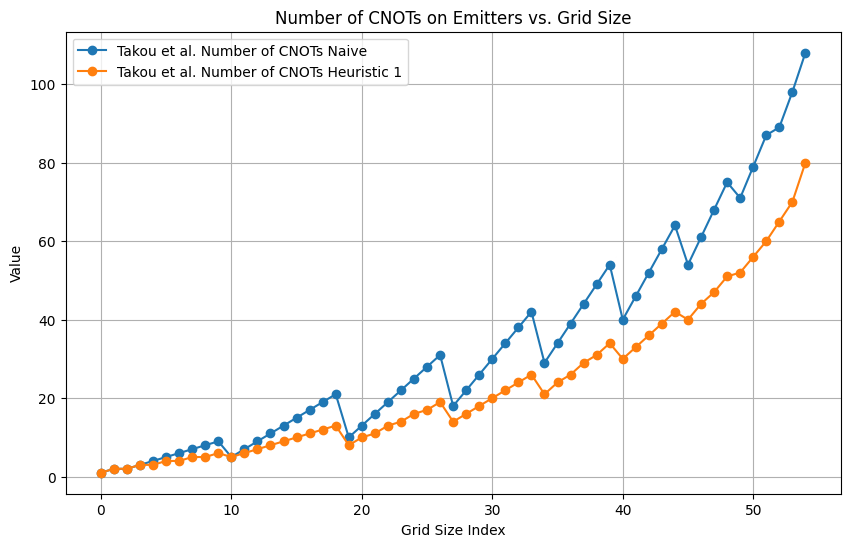

In [32]:
# Create the line plot for emitters_Naive
plt.figure(figsize=(10, 6))
plt.plot(range(len(cnots_Naive)), cnots_Naive, marker='o',label='Takou et al. Number of CNOTs Naive')

# Create the line plot for cnots_Naive
plt.plot(range(len(cnots_Heur1)), cnots_Heur1, marker='o',label='Takou et al. Number of CNOTs Heuristic 1')

# Set the labels
plt.xlabel('Grid Size Index')
plt.ylabel('Value')

# Set the title
plt.title('Number of CNOTs on Emitters vs. Grid Size')

# Add legend
plt.legend()

# Set the y-axis to show only integers
# plt.yticks(range(min(min(emitters_Naive), min(cnots_Naive)), max(max(emitters_Naive), max(cnots_Naive))+1))

# Add a grid to the plot
plt.grid(True)

# Show the plot
plt.show()

### SAminLA Simulations

In [ ]:
#Recalculate the same for our algorithm 
number_of_emitters = []
number_of_emitter_CNOTs = []
max_n = 11
max_m = 11

chosen_minLA_sett={'temperature': 2000, 'cooling_rate': 0.7, 'iterations': 6000}

for n in range(2, max_n+1):
    for m in range(n, max_m+1):
        print(f"Running optimization for grid graph of size {n}x{m}")
        grid_graph = nx.grid_graph(dim=[n, m])
        # Relabel the nodes to integers
        grid_graph = nx.relabel_nodes(grid_graph, {node: i for i, node in enumerate(grid_graph.nodes())})
        # Run the optimization scheme on the grid graph
        opt_graph, circuit, stats = run_optimization(grid_graph, minLA_sett=chosen_minLA_sett)
        number_of_emitters.append(stats[0])
        number_of_emitter_CNOTs.append(stats[1])
        np.savetxt(f'number_of_emitters_cooling{chosen_minLA_sett["cooling_rate"]}_iterations{chosen_minLA_sett["iterations"]}_temp{chosen_minLA_sett["temperature"]}.txt', number_of_emitters, fmt='%d')
        np.savetxt(f'number_of_cnots_cooling{chosen_minLA_sett["cooling_rate"]}_iterations{chosen_minLA_sett["iterations"]}_temp{chosen_minLA_sett["temperature"]}.txt', number_of_emitter_CNOTs, fmt='%d')

Running optimization for grid graph of size 2x2
Running optimization for grid graph of size 2x3
Running optimization for grid graph of size 2x4
Running optimization for grid graph of size 2x5
Running optimization for grid graph of size 2x6
Running optimization for grid graph of size 2x7
Running optimization for grid graph of size 2x8
Running optimization for grid graph of size 2x9
Running optimization for grid graph of size 2x10
Running optimization for grid graph of size 2x11
Running optimization for grid graph of size 3x3
Running optimization for grid graph of size 3x4
Running optimization for grid graph of size 3x5
Running optimization for grid graph of size 3x6
Running optimization for grid graph of size 3x7
Running optimization for grid graph of size 3x8
Running optimization for grid graph of size 3x9
Running optimization for grid graph of size 3x10
Running optimization for grid graph of size 3x11
Running optimization for grid graph of size 4x4
Running optimization for grid graph 

In [35]:
# save the files
np.savetxt(f'number_of_emitters_cooling{chosen_minLA_sett["cooling_rate"]}_iterations{chosen_minLA_sett["iterations"]}_temp{chosen_minLA_sett["temperature"]}.txt', number_of_emitters, fmt='%d')

# Print the contents of the file
with open(f'number_of_emitters_cooling{chosen_minLA_sett["cooling_rate"]}_iterations{chosen_minLA_sett["iterations"]}_temp{chosen_minLA_sett["temperature"]}.txt', 'r') as file:
    number_of_emitters_new = file.read()
    print(contents)


# save the files
np.savetxt(f'number_of_cnots_cooling{chosen_minLA_sett["cooling_rate"]}_iterations{chosen_minLA_sett["iterations"]}_temp{chosen_minLA_sett["temperature"]}.txt', number_of_emitter_CNOTs, fmt='%d')

# Print the contents of the file
with open(f'number_of_cnots_cooling{chosen_minLA_sett["cooling_rate"]}_iterations{chosen_minLA_sett["iterations"]}_temp{chosen_minLA_sett["temperature"]}.txt', 'r') as file:
    number_of_cnots_new = file.read()
    print(contents)


[108,11,80,11]
[108,11,80,11]


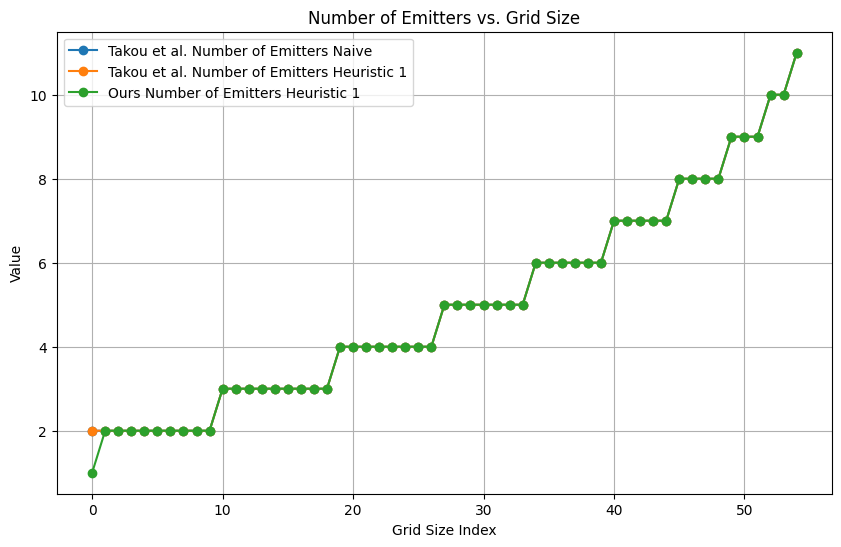

In [36]:
# Create the line plot for emitters_Naive
plt.figure(figsize=(10, 6))
plt.plot(range(len(emitters_Naive)), emitters_Naive, marker='o',label='Takou et al. Number of Emitters Naive')

# Create the line plot for cnots_Naive
plt.plot(range(len(emitters_Heu1)), emitters_Heu1,marker='o' ,label='Takou et al. Number of Emitters Heuristic 1')

plt.plot(range(len(number_of_emitters)), number_of_emitters,marker='o' ,label='Ours Number of Emitters Heuristic 1')

# plt.plot(range(len(number_of_emitters_new)), number_of_emitters_new,marker='o' ,label='Ours Number of Emitters Heuristic 1')


# Set the labels
plt.xlabel('Grid Size Index')
plt.ylabel('Value')

# Set the title
plt.title('Number of Emitters vs. Grid Size')

# Add legend
plt.legend()

# Set the y-axis to show only integers
# plt.yticks(range(min(min(emitters_Naive), min(cnots_Naive)), max(max(emitters_Naive), max(cnots_Naive))+1))

# Add a grid to the plot
plt.grid(True)

# Show the plot
plt.show()

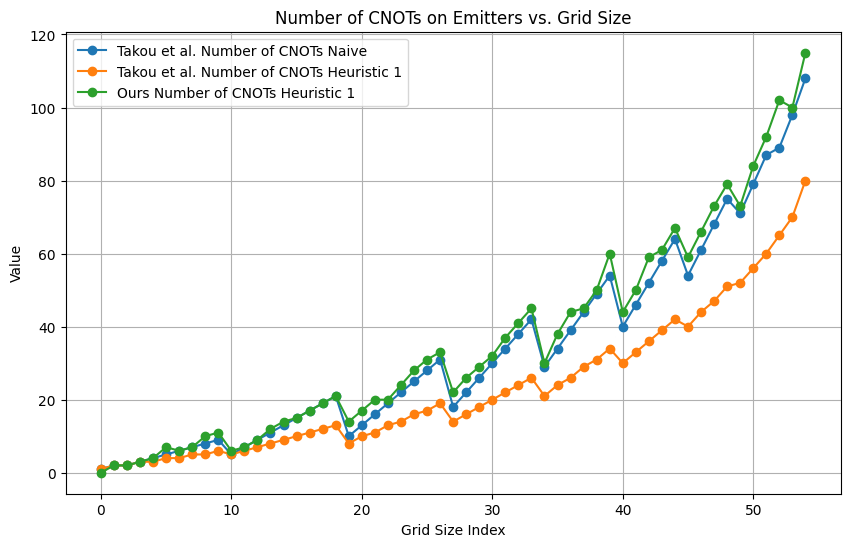

In [37]:
# Create the line plot for emitters_Naive
plt.figure(figsize=(10, 6))
plt.plot(range(len(cnots_Naive)), cnots_Naive, marker='o',label='Takou et al. Number of CNOTs Naive')

# Create the line plot for cnots_Naive
plt.plot(range(len(cnots_Heur1)), cnots_Heur1, marker='o',label='Takou et al. Number of CNOTs Heuristic 1')

plt.plot(range(len(number_of_emitter_CNOTs)), number_of_emitter_CNOTs, marker='o',label='Ours Number of CNOTs Heuristic 1')

# Set the labels
plt.xlabel('Grid Size Index')
plt.ylabel('Value')

# Set the title
plt.title('Number of CNOTs on Emitters vs. Grid Size')

# Add legend
plt.legend()

# Set the y-axis to show only integers
# plt.yticks(range(min(min(emitters_Naive), min(cnots_Naive)), max(max(emitters_Naive), max(cnots_Naive))+1))

# Add a grid to the plot
plt.grid(True)

# Show the plot
plt.show()

#### Multiple SAminLA Sims

In [42]:
simulation_setups = [
    {'temperature': 2000, 'cooling_rate': 0.6, 'iterations': 40000},
    
]

max_n = 11
max_m = 11

for setup in simulation_setups:

    print("\n======================================")
    print("Running setup:", setup)
    print("======================================\n")

    number_of_emitters = []
    number_of_emitter_CNOTs = []

    for n in range(2, max_n + 1):
        for m in range(n, max_m + 1):

            print(f"Running optimization for grid graph of size {n}x{m}")

            grid_graph = nx.grid_graph(dim=[n, m])
            grid_graph = nx.relabel_nodes(grid_graph, 
                                          {node: i for i, node in enumerate(grid_graph.nodes())})

            opt_graph, circuit, stats = run_optimization(grid_graph, minLA_sett=setup)

            number_of_emitters.append(stats[0])
            number_of_emitter_CNOTs.append(stats[1])

    # --- Save the results for this setup ---
    base = (
        f"cooling{setup['cooling_rate']}"
        f"_iterations{setup['iterations']}"
        f"_temp{setup['temperature']}"
    )

    np.savetxt(f'number_of_emitters_{base}.txt', number_of_emitters, fmt='%d')
    np.savetxt(f'number_of_cnots_{base}.txt', number_of_emitter_CNOTs, fmt='%d')

    print(f"\nSaved results for setup {setup} as:")
    print(f"  number_of_emitters_{base}.txt")
    print(f"  number_of_cnots_{base}.txt")



Running setup: {'temperature': 2000, 'cooling_rate': 0.6, 'iterations': 40000}

Running optimization for grid graph of size 2x2
Running optimization for grid graph of size 2x3
Running optimization for grid graph of size 2x4
Running optimization for grid graph of size 2x5
Running optimization for grid graph of size 2x6
Running optimization for grid graph of size 2x7
Running optimization for grid graph of size 2x8
Running optimization for grid graph of size 2x9
Running optimization for grid graph of size 2x10
Running optimization for grid graph of size 2x11
Running optimization for grid graph of size 3x3
Running optimization for grid graph of size 3x4
Running optimization for grid graph of size 3x5
Running optimization for grid graph of size 3x6
Running optimization for grid graph of size 3x7
Running optimization for grid graph of size 3x8
Running optimization for grid graph of size 3x9
Running optimization for grid graph of size 3x10
Running optimization for grid graph of size 3x11
Run

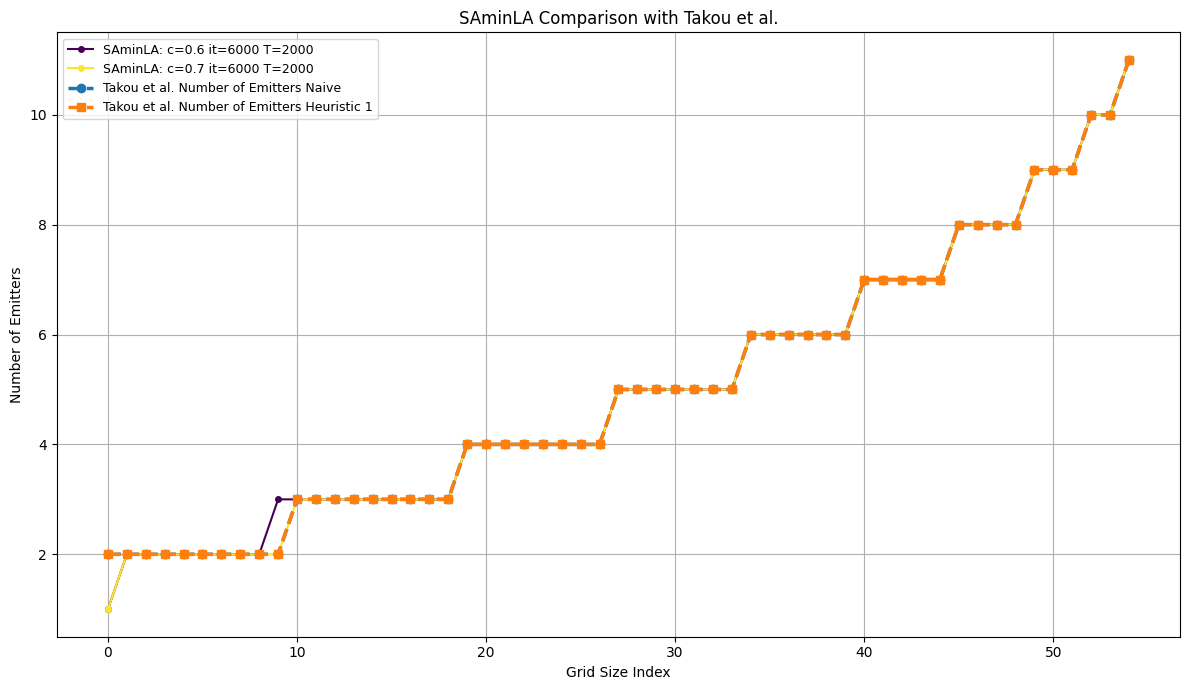

In [39]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

#SAminLA data
folder = "/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/"

pattern = r"number_of_emitters_cooling([0-9.]+)_iterations(\d+)_temp(\d+)\.txt"

runs = []


#  Load all simulation runs

for fname in os.listdir(folder):
    match = re.match(pattern, fname)
    if match:
        cooling = float(match.group(1))
        iterations = int(match.group(2))
        temp = int(match.group(3))

        filepath = os.path.join(folder, fname)

        with open(filepath, "r") as f:
            data = [float(x.strip()) for x in f if x.strip()]

        runs.append({
            "cooling": cooling,
            "iterations": iterations,
            "temp": temp,
            "data": data,
            "filename": fname
        })


#  Sort by (cooling, iterations)

runs = sorted(runs, key=lambda x: (x["cooling"], x["iterations"]))


#  Colormap based on cooling

coolings = np.array([run["cooling"] for run in runs])
norm = (coolings - coolings.min()) / (coolings.max() - coolings.min() + 1e-12)
cmap = plt.cm.viridis
colors = cmap(norm)


#  Plot everything together

plt.figure(figsize=(12, 7))


for run, color in zip(runs, colors):
    label = f"SAminLA: c={run['cooling']} it={run['iterations']} T={run['temp']}"
    plt.plot(
        run["data"],
        color=color,
        linewidth=1.5,
        marker='o',
        markersize=4,
        label=label
    )


plt.plot(
    range(len(emitters_Naive)),
    emitters_Naive,
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of Emitters Naive'
)

plt.plot(
    range(len(emitters_Heu1)),
    emitters_Heu1,
    marker='s',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of Emitters Heuristic 1'
)


#  Labels and layout

plt.xlabel("Grid Size Index")
plt.ylabel("Number of Emitters")
plt.title("SAminLA Comparison with Takou et al.")
plt.grid(True)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()

plt.show()


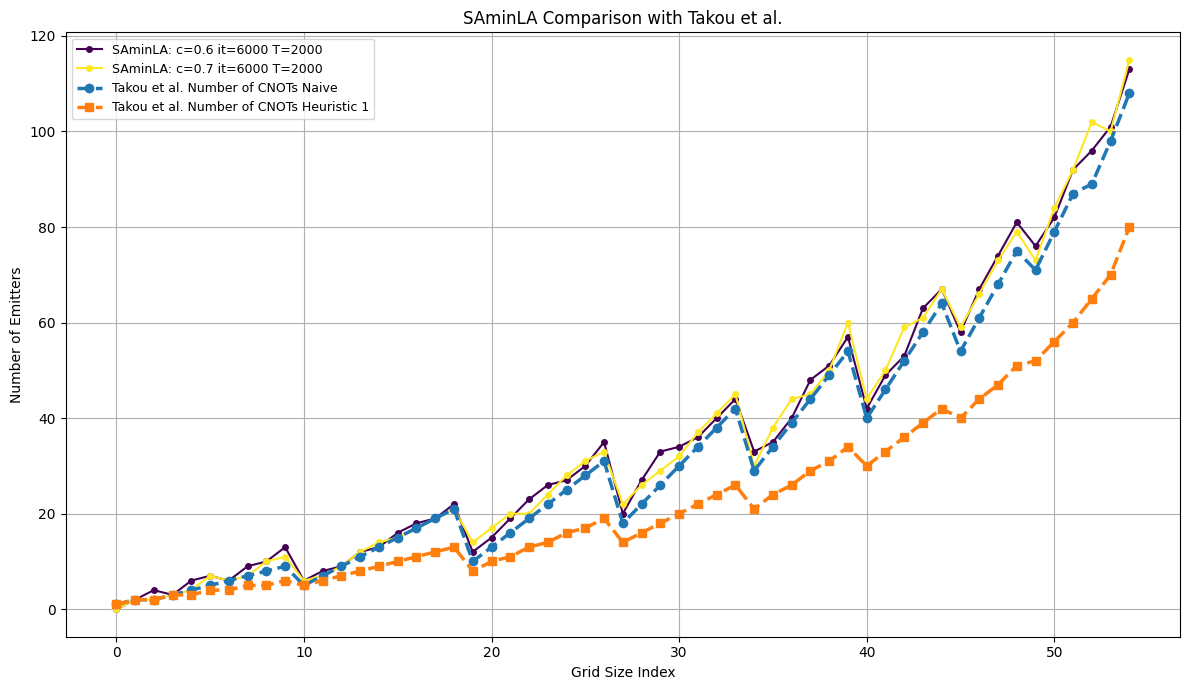

In [40]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np

#SAminLA data
folder = "/Users/konstantinosrafailrevis/Desktop/PhD/0paul_state_gen/photonic-graphstate-generator-main/"

pattern = r"number_of_cnots_cooling([0-9.]+)_iterations(\d+)_temp(\d+)\.txt"

runs = []


#  Load all simulation runs

for fname in os.listdir(folder):
    match = re.match(pattern, fname)
    if match:
        cooling = float(match.group(1))
        iterations = int(match.group(2))
        temp = int(match.group(3))

        filepath = os.path.join(folder, fname)

        with open(filepath, "r") as f:
            data = [float(x.strip()) for x in f if x.strip()]

        runs.append({
            "cooling": cooling,
            "iterations": iterations,
            "temp": temp,
            "data": data,
            "filename": fname
        })


#  Sort by (cooling, iterations)

runs = sorted(runs, key=lambda x: (x["cooling"], x["iterations"]))


#  Colormap based on cooling

coolings = np.array([run["cooling"] for run in runs])
norm = (coolings - coolings.min()) / (coolings.max() - coolings.min() + 1e-12)
cmap = plt.cm.viridis
colors = cmap(norm)


#  Plot everything together

plt.figure(figsize=(12, 7))


for run, color in zip(runs, colors):
    label = f"SAminLA: c={run['cooling']} it={run['iterations']} T={run['temp']}"
    plt.plot(
        run["data"],
        color=color,
        linewidth=1.5,
        marker='o',
        markersize=4,
        label=label
    )


plt.plot(
    range(len(cnots_Naive)),
    cnots_Naive,
    marker='o',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of CNOTs Naive'
)

plt.plot(
    range(len(cnots_Heur1)),
    cnots_Heur1,
    marker='s',
    linestyle='--',
    linewidth=2.5,
    label='Takou et al. Number of CNOTs Heuristic 1'
)


#  Labels and layout

plt.xlabel("Grid Size Index")
plt.ylabel("Number of Emitters")
plt.title("SAminLA Comparison with Takou et al.")
plt.grid(True)
plt.legend(loc="best", fontsize=9)
plt.tight_layout()

plt.show()
